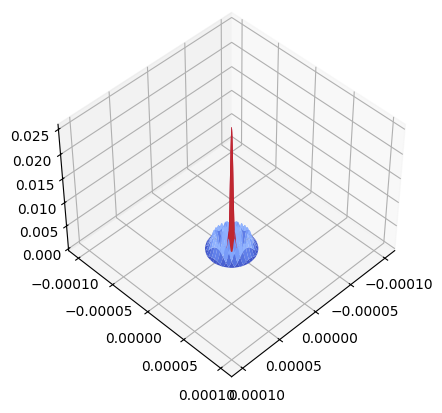

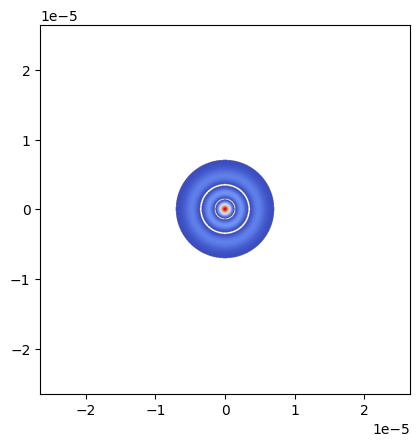

5.305305305305305e-05


In [3]:
from scipy.special import hermite, genlaguerre
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def w(z, w0, n = 1, wavlen = 1064e-9):
    return w0 * np.sqrt(1 + np.power(z / (np.pi * w0 ** 2 * n / wavlen), 2)) 
def intensity(I0, w0, m, n, x, mu_x, y, mu_y, z):
    return I0 * (w0 / w(z, w0)) ** 2 * (hermite(m)(np.sqrt(2) * (x - mu_x) / w(z, w0)) * np.exp(- (x - mu_x) ** 2 / w(z, w0) ** 2)) ** 2 * (hermite(n)(np.sqrt(2) * (y  - mu_y)/ w(z, w0)) * np.exp(- (y  - mu_y)** 2 / w(z, w0) ** 2)) ** 2
def L_intensity(I0, w0, p, l, x, mu_x, y, mu_y, phi, z):
    return I0 * (2 * np.sqrt((x - mu_x) ** 2 + (y - mu_y) ** 2) ** 2 / w(z, w0) ** 2) ** l * (genlaguerre(p, l)(2 * np.sqrt((x - mu_x) ** 2 + (y - mu_y) ** 2) ** 2 / w(z, w0) ** 2)) ** 2 * np.cos(l * phi) ** 2 * np.exp(- 2 * np.sqrt((x - mu_x) ** 2 + (y - mu_y) ** 2) ** 2 / w(z, w0) ** 2)
x = np.linspace(-1e-4, 1e-4, 1000)
y = np.linspace(-1e-4, 1e-4, 1000)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"})
xyz = np.column_stack([X.flat, Y.flat, L_intensity(100, 1e-5, 2, 0, np.array(X.flat), 0, np.array(Y.flat), 0, np.arctan(np.array(Y.flat) / np.array(X.flat)), 0)])
xyz[:, 2] = 100 * xyz[:, 2] / np.sum(xyz[:, 2])
xyz[np.ix_(np.where(np.abs(xyz[:, 2]) < 1e-4)[0], [2])] = np.nan
ax.plot_surface(*[xyz[:, i].reshape(int(np.sqrt(len(xyz[:, i]))), int(np.sqrt(len(xyz[:, i])))) for i in range(3)], cmap = cm.coolwarm)
ax.view_init(elev = 45, azim = 45, roll = 0)
plt.show()
fig, ax = plt.subplots(1, 1)
ax.imshow(xyz[:, 2].reshape(int(np.sqrt(len(xyz[:, 2]))), int(np.sqrt(len(xyz[:, 2])))), cmap = cm.coolwarm, extent = [np.min(xyz[:, 0][np.isnan(xyz[:, 2]) == False]), np.max(xyz[:, 0][np.isnan(xyz[:, 2]) == False]), np.min(xyz[:, 1][np.isnan(xyz[:, 2]) == False]), np.max(xyz[:, 1][np.isnan(xyz[:, 2]) == False])])
plt.show()
print(np.max(xyz[:, 0][np.isnan(xyz[:, 2]) == False]) - np.min(xyz[:, 0][np.isnan(xyz[:, 2]) == False]))

89.6550667442316


(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

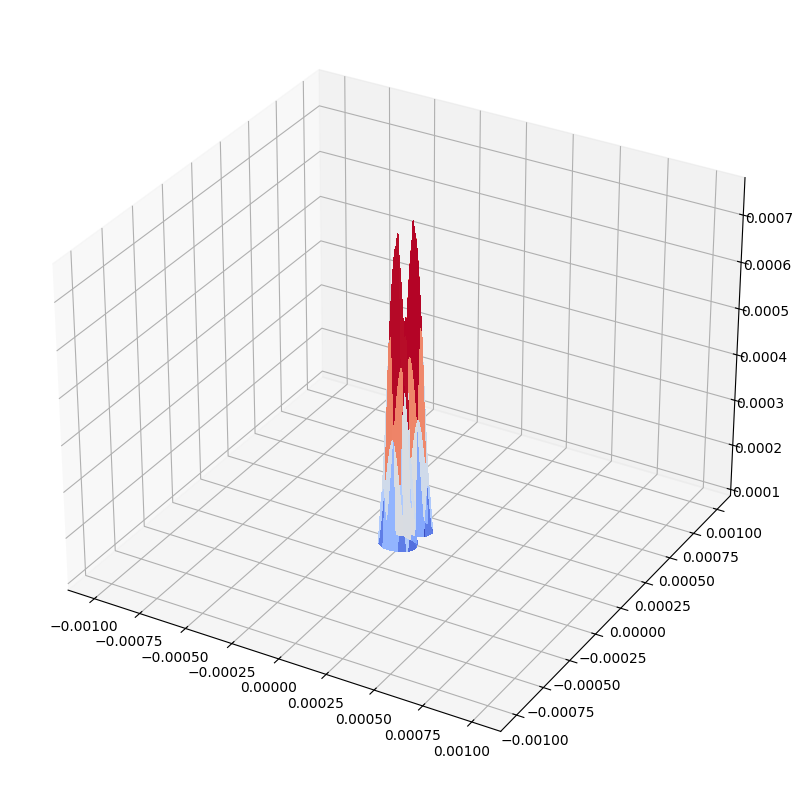

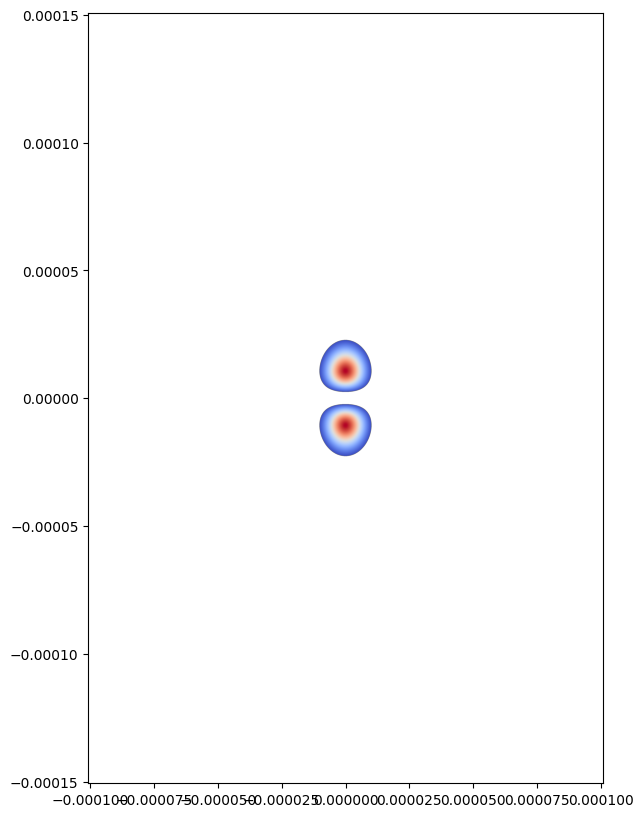

In [13]:
import laser
import numpy as np
l = laser.Laser(0, 0, 0, waist = 1e-4, power = 102, res = 5000, mode = [0, 1], mode_type = "h", chop = True, chop_threshold = 1e-4)
print(np.sum(l.xyz[:, 2][np.isnan(l.xyz[:, 2]) == False]))
# l.xyz[np.ix_(np.where(np.abs(l.xyz[:, 2]) < 1e-5)[0], [2])] = np.nan
# print(len(l.xyz))
# print(l.xyz[:, 2][np.where(np.isnan(l.xyz[:, 2]) == False)])
l.plot_surface()
l.imshow()

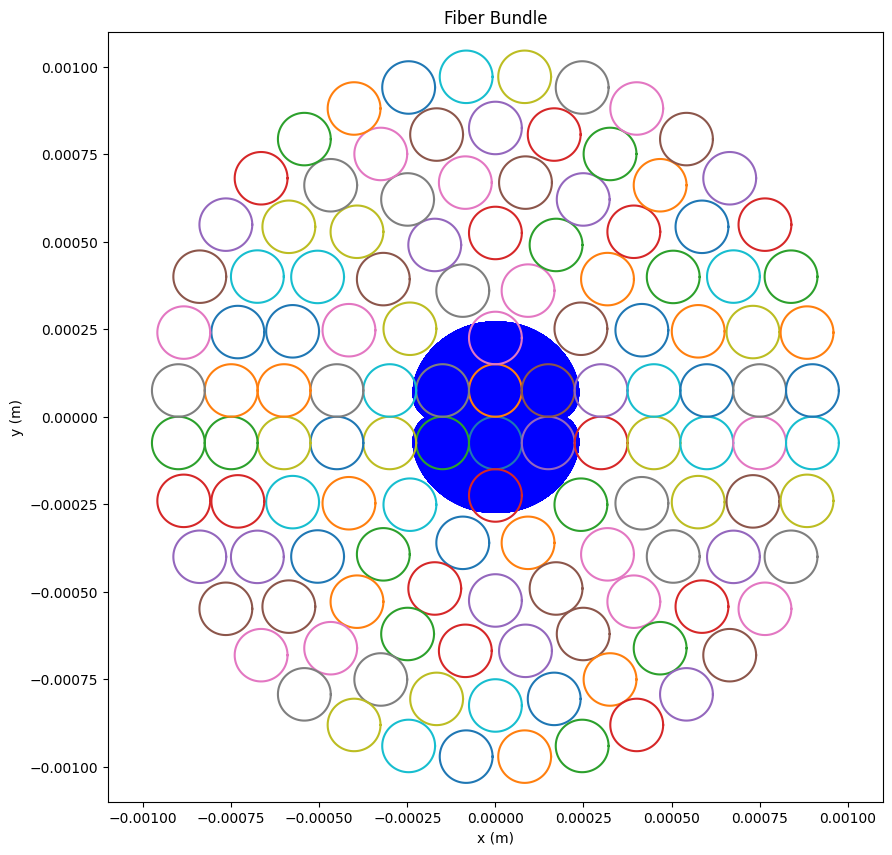

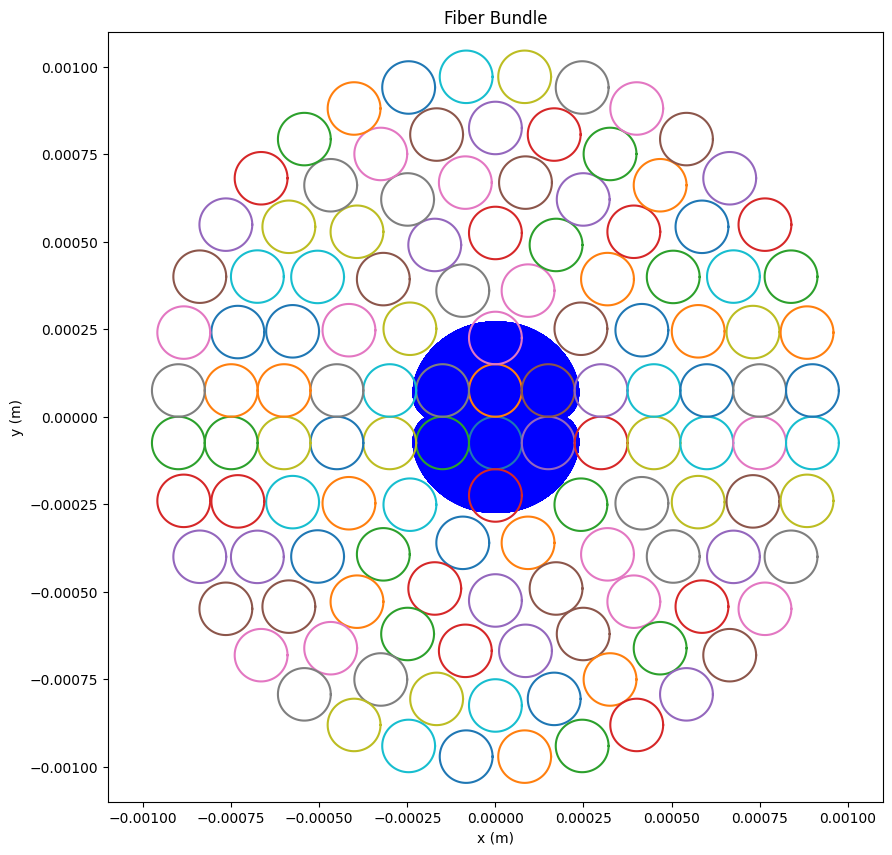

0.0


In [14]:
import fiber
import laser
import numpy as np
import matplotlib.pyplot as plt

l = laser.Laser(0, 0, 0, waist = 1e-4, power = 102000, res = 10000, mode = [0, 1], mode_type = "h", chop = True, chop_threshold = 1e-5)
bundle = fiber.FiberBundle(1e-3, 2.5e-5, 5e-5)

fig, ax = bundle.plot(im = l)
# ax.set_xlim(-1e-4, 1e-4)
# ax.set_ylim(-1e-4, 1e-4)
plt.show()
first = bundle.diff_power(l)
l.dy(1e-12)
fig, ax = bundle.plot(im = l)
# ax.set_xlim(-1e-4, 1e-4)
# ax.set_ylim(-1e-4, 1e-4)
plt.show()
second = bundle.diff_power(l)
print(first - second)